<img src= "./images/ml_loan_banner.jpg" width = "800">
</img>


<h2 style= "color: #F4C300; text-align: left; font-weight: bold;">
Loan Approval and Credit Risk Assessment
</h2>

<h3 style= "color: #F4C300; text-align: left; font-weight: bold;">
Project Overview
</h3>

This project develops a machine learning classification model to support loan approval decisions using historical applicant, financial, and credit data from 20,000 past loan applications. The analysis follows the CRISP-DM framework, progressing from understanding the business problem and exploring the data to preprocessing, model development, and evaluation.

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
1. Business Understanding
</h3>

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
1.1. Business Context
</h4>
FinTech Innovations partners with traditional banks to improve their loan approval processes. The current process relies heavily on manual review by loan officers, which can result in slower application processing and inconsistent lending decisions. The goal of this project is to develop a machine learning solution that uses historical applicant information to support faster, more consistent, and data-driven loan approval decisions while maintaining appropriate oversight.

The key stakeholders include loan applicants, who need timely and fair decisions; loan officers, who need reliable information to support their assessments; risk management teams, who need to minimize exposure to high-risk lending; and FinTech Innovations and its banking partners, who need an efficient and financially sustainable approval process.

Incorrect predictions have different financial consequences. A false positive, where the model recommends approval for a loan that should not be approved and subsequently defaults, has an estimated average cost of $50,000. A false negative, where the model rejects a creditworthy applicant, represents approximately $8,000 in lost potential profit. Therefore, false approvals are considerably more costly to the business than false denials, although both errors need to be considered when evaluating the model.

This project will use a classification approach, with LoanApproved as the target variable, where 1 represents an approved loan and 0 represents a denied loan. Classification is appropriate because the objective is to predict one of two possible loan approval outcomes rather than a continuous numerical value. The dataset also contains a RiskScore variable, but the primary objective of this analysis will be predicting the historical loan approval decision.


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
1.2. Modeling Goals and Success Criteria
</h4>
The primary modeling goal is to develop a classification model that can distinguish between approved and denied loan applications while accounting for the unequal financial consequences of prediction errors. Precision, recall, F1-score, and ROC-AUC will be evaluated rather than relying on accuracy alone. Precision is particularly important because false approvals carry a high financial cost, while recall is also important because rejecting creditworthy applicants results in lost business opportunities. F1-score will help assess the balance between precision and recall, while ROC-AUC will measure the model's ability to distinguish between the two classes across different classification thresholds.

In addition to standard classification metrics, a custom business-cost metric will be used to translate prediction errors into their estimated financial impact. Based on the business assumptions provided, the estimated cost will be calculated as ($50,000 × false positives) + ($8,000 × false negatives). This will allow models with similar statistical performance to be compared based on their potential financial consequences.

A baseline model will also be established before developing more advanced models. Because the dataset contains an imbalanced target, a simple majority-class classifier will provide a reference point for evaluating whether the machine learning models offer meaningful improvement. The final model should outperform this baseline on relevant classification metrics and should reduce the estimated business cost of incorrect decisions. Model interpretability will also be considered because loan approval decisions need to be understandable to business and risk stakeholders.

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
2. Data Understanding
</h3>

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.1. Dataset Overview
</h4>

This section explores the loan application dataset to understand its structure, feature types, distributions, relationships, and potential data quality issues. The analysis further examines the distribution of the `LoanApproved` target variable and identifies features that may require cleaning, transformation or further investigation before model development.

In [99]:
# Import of required modules

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

In [100]:
# Loading in the data
df = pd.read_csv("financial_loan_data.csv")

# view the first few rows
df.head()


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [101]:
df.shape

(20000, 35)

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

The dataset contains **20,000 loan applications and 35 features**, with each row representing an individual loan application. The columns contain demographic, financial, credit, employment, and loan-related information, together with the `LoanApproved` target variable.

In [102]:
# now we inspect the columns names
df.columns.tolist()

['Age',
 'AnnualIncome',
 'CreditScore',
 'EmploymentStatus',
 'EducationLevel',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'MaritalStatus',
 'NumberOfDependents',
 'HomeOwnershipStatus',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'BankruptcyHistory',
 'LoanPurpose',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'LoanApproved',
 'RiskScore']

In [103]:
# we then inspect the data types and non null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.2. Feature Types
</h4>

In [104]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 28
Number of categorical features: 7

Numerical features:
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical features:
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

Most features are stored using data types that are consistent with their expected meaning. However, `AnnualIncome` is stored as an `object` rather than a numerical variable because its values contain currency formatting such as dollar signs and commas. This feature will require conversion to a numerical data type during data preparation.

Some integer variables, such as `LoanApproved` and `PreviousLoanDefaults`, may represent categorical or binary information rather than continuous numerical measurements. Therefore, pandas data types alone will not be used to determine how each feature is treated during preprocessing.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.3. Descriptive Statistics
</h4>


In [105]:
# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [106]:
# Summary statistics for categorical features
df.describe(include="object").T

,count,unique,top,freq
AnnualIncome,20000,17516,"$15,000.00",584
EmploymentStatus,20000,3,Employed,17036
EducationLevel,19099,5,Bachelor,5804
MaritalStatus,18669,4,Married,9370
HomeOwnershipStatus,20000,4,Mortgage,7939
BankruptcyHistory,20000,2,No,18952
LoanPurpose,20000,5,Home,5925


In [107]:
# Number of unique values in each column
df.nunique().sort_values()

PreviousLoanDefaults              2
LoanApproved                      2
BankruptcyHistory                 2
EmploymentStatus                  3
MaritalStatus                     4
HomeOwnershipStatus               4
LoanPurpose                       5
EducationLevel                    5
NumberOfDependents                6
NumberOfCreditInquiries           8
LoanDuration                     10
NumberOfOpenCreditLines          14
JobTenure                        17
LengthOfCreditHistory            29
PaymentHistory                   38
Experience                       62
Age                              63
RiskScore                        73
CreditScore                     322
MonthlyDebtPayments            1299
CheckingAccountBalance         5151
SavingsAccountBalance          9054
LoanAmount                    15578
TotalLiabilities              17163
MonthlyIncome                 17489
AnnualIncome                  17516
NetWorth                      17724
BaseInterestRate            

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.4. Data Quality Assessment
</h4>


In [108]:
# Count missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

In [109]:
# percentage of missing values
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

MaritalStatus            6.655
EducationLevel           4.505
SavingsAccountBalance    2.860
dtype: float64


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

Missing values are present in `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance`. The proportion of missing data is relatively small, but the appropriate treatment may differ by feature. The categorical variables `MaritalStatus` and `EducationLevel` may require categorical imputation, while `SavingsAccountBalance` is numerical and may require a numerical imputation strategy.

The missing values will not be removed at this stage because doing so without understanding their patterns could unnecessarily discard useful observations or introduce bias. Appropriate imputation strategies will be considered during data preparation.

In [110]:
# Check for duplicate observations
df.duplicated().sum()

0

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

No fully duplicated rows were identified in the dataset, it meand that its not an immediate problem we have

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.5. Target Variable Analysis
</h4>

In [111]:
# Target class counts
df["LoanApproved"].value_counts()

LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [112]:
# Target class proportions
df["LoanApproved"].value_counts(normalize=True) * 100

LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64

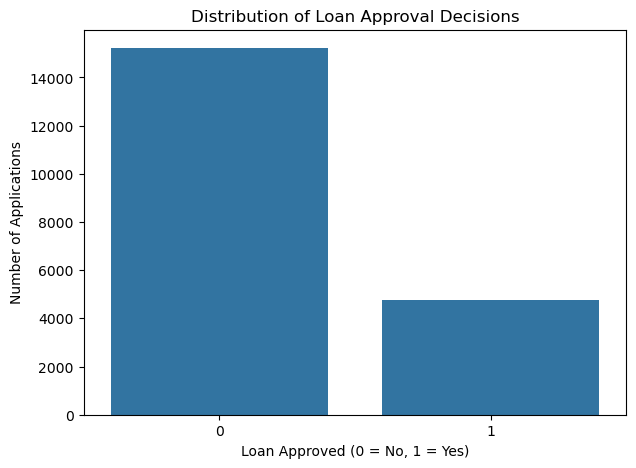

In [113]:
# Visualization

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="LoanApproved")

plt.title("Distribution of Loan Approval Decisions")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Number of Applications")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.6. Feature Categories
</h4>

For preprocessing purposes, the features can broadly be categorized as follows:

- **Numerical features:** Variables representing measurable quantities, including `Age`, `CreditScore`, `Experience`, `LoanAmount`, `MonthlyDebtPayments`, `CreditCardUtilizationRate`, `DebtToIncomeRatio`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `MonthlyIncome`, `NetWorth`, and related financial measures.

- **Categorical features:** Variables representing groups or labels, including `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory`, and `LoanPurpose`.

- **Ordinal features:** `EducationLevel` may contain categories with a meaningful educational progression and will be investigated to determine whether ordinal encoding is appropriate.

- **Discrete features:** Variables such as `PreviousLoanDefaults` and `LoanApproved` represent discrete outcomes rather than continuous measurements.

Some variables require additional investigation before final preprocessing decisions are made. In particular, `AnnualIncome` should be numerical but is currently stored as text because of currency formatting.

In [114]:
df["EducationLevel"].value_counts(dropna=False)

EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

In [115]:
for column in categorical_features:
    print(f"\n{column}")
    print("-" * 40)
    print(df[column].value_counts(dropna=False))


AnnualIncome
----------------------------------------
AnnualIncome
$15,000.00     584
$300,000.00     26
$68,064.00       4
$24,627.00       4
$36,604.00       4
              ... 
$48,316.00       1
$50,463.00       1
$25,001.00       1
$22,593.00       1
$53,227.00       1
Name: count, Length: 17516, dtype: int64

EmploymentStatus
----------------------------------------
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
----------------------------------------
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
NaN             901
Name: count, dtype: int64

MaritalStatus
----------------------------------------
MaritalStatus
Married     9370
Single      5665
Divorced    2704
NaN         1331
Widowed      930
Name: count, dtype: int64

HomeOwnershipStatus
----------------------------------------
HomeOwnershipStatus
Mortgage    7939
Rent        6

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.7. Numerical Feature Distributions
</h4>


In [116]:
# Numerical features excluding the target
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if "LoanApproved" in numeric_cols:
    numeric_cols.remove("LoanApproved")

len(numeric_cols)

27

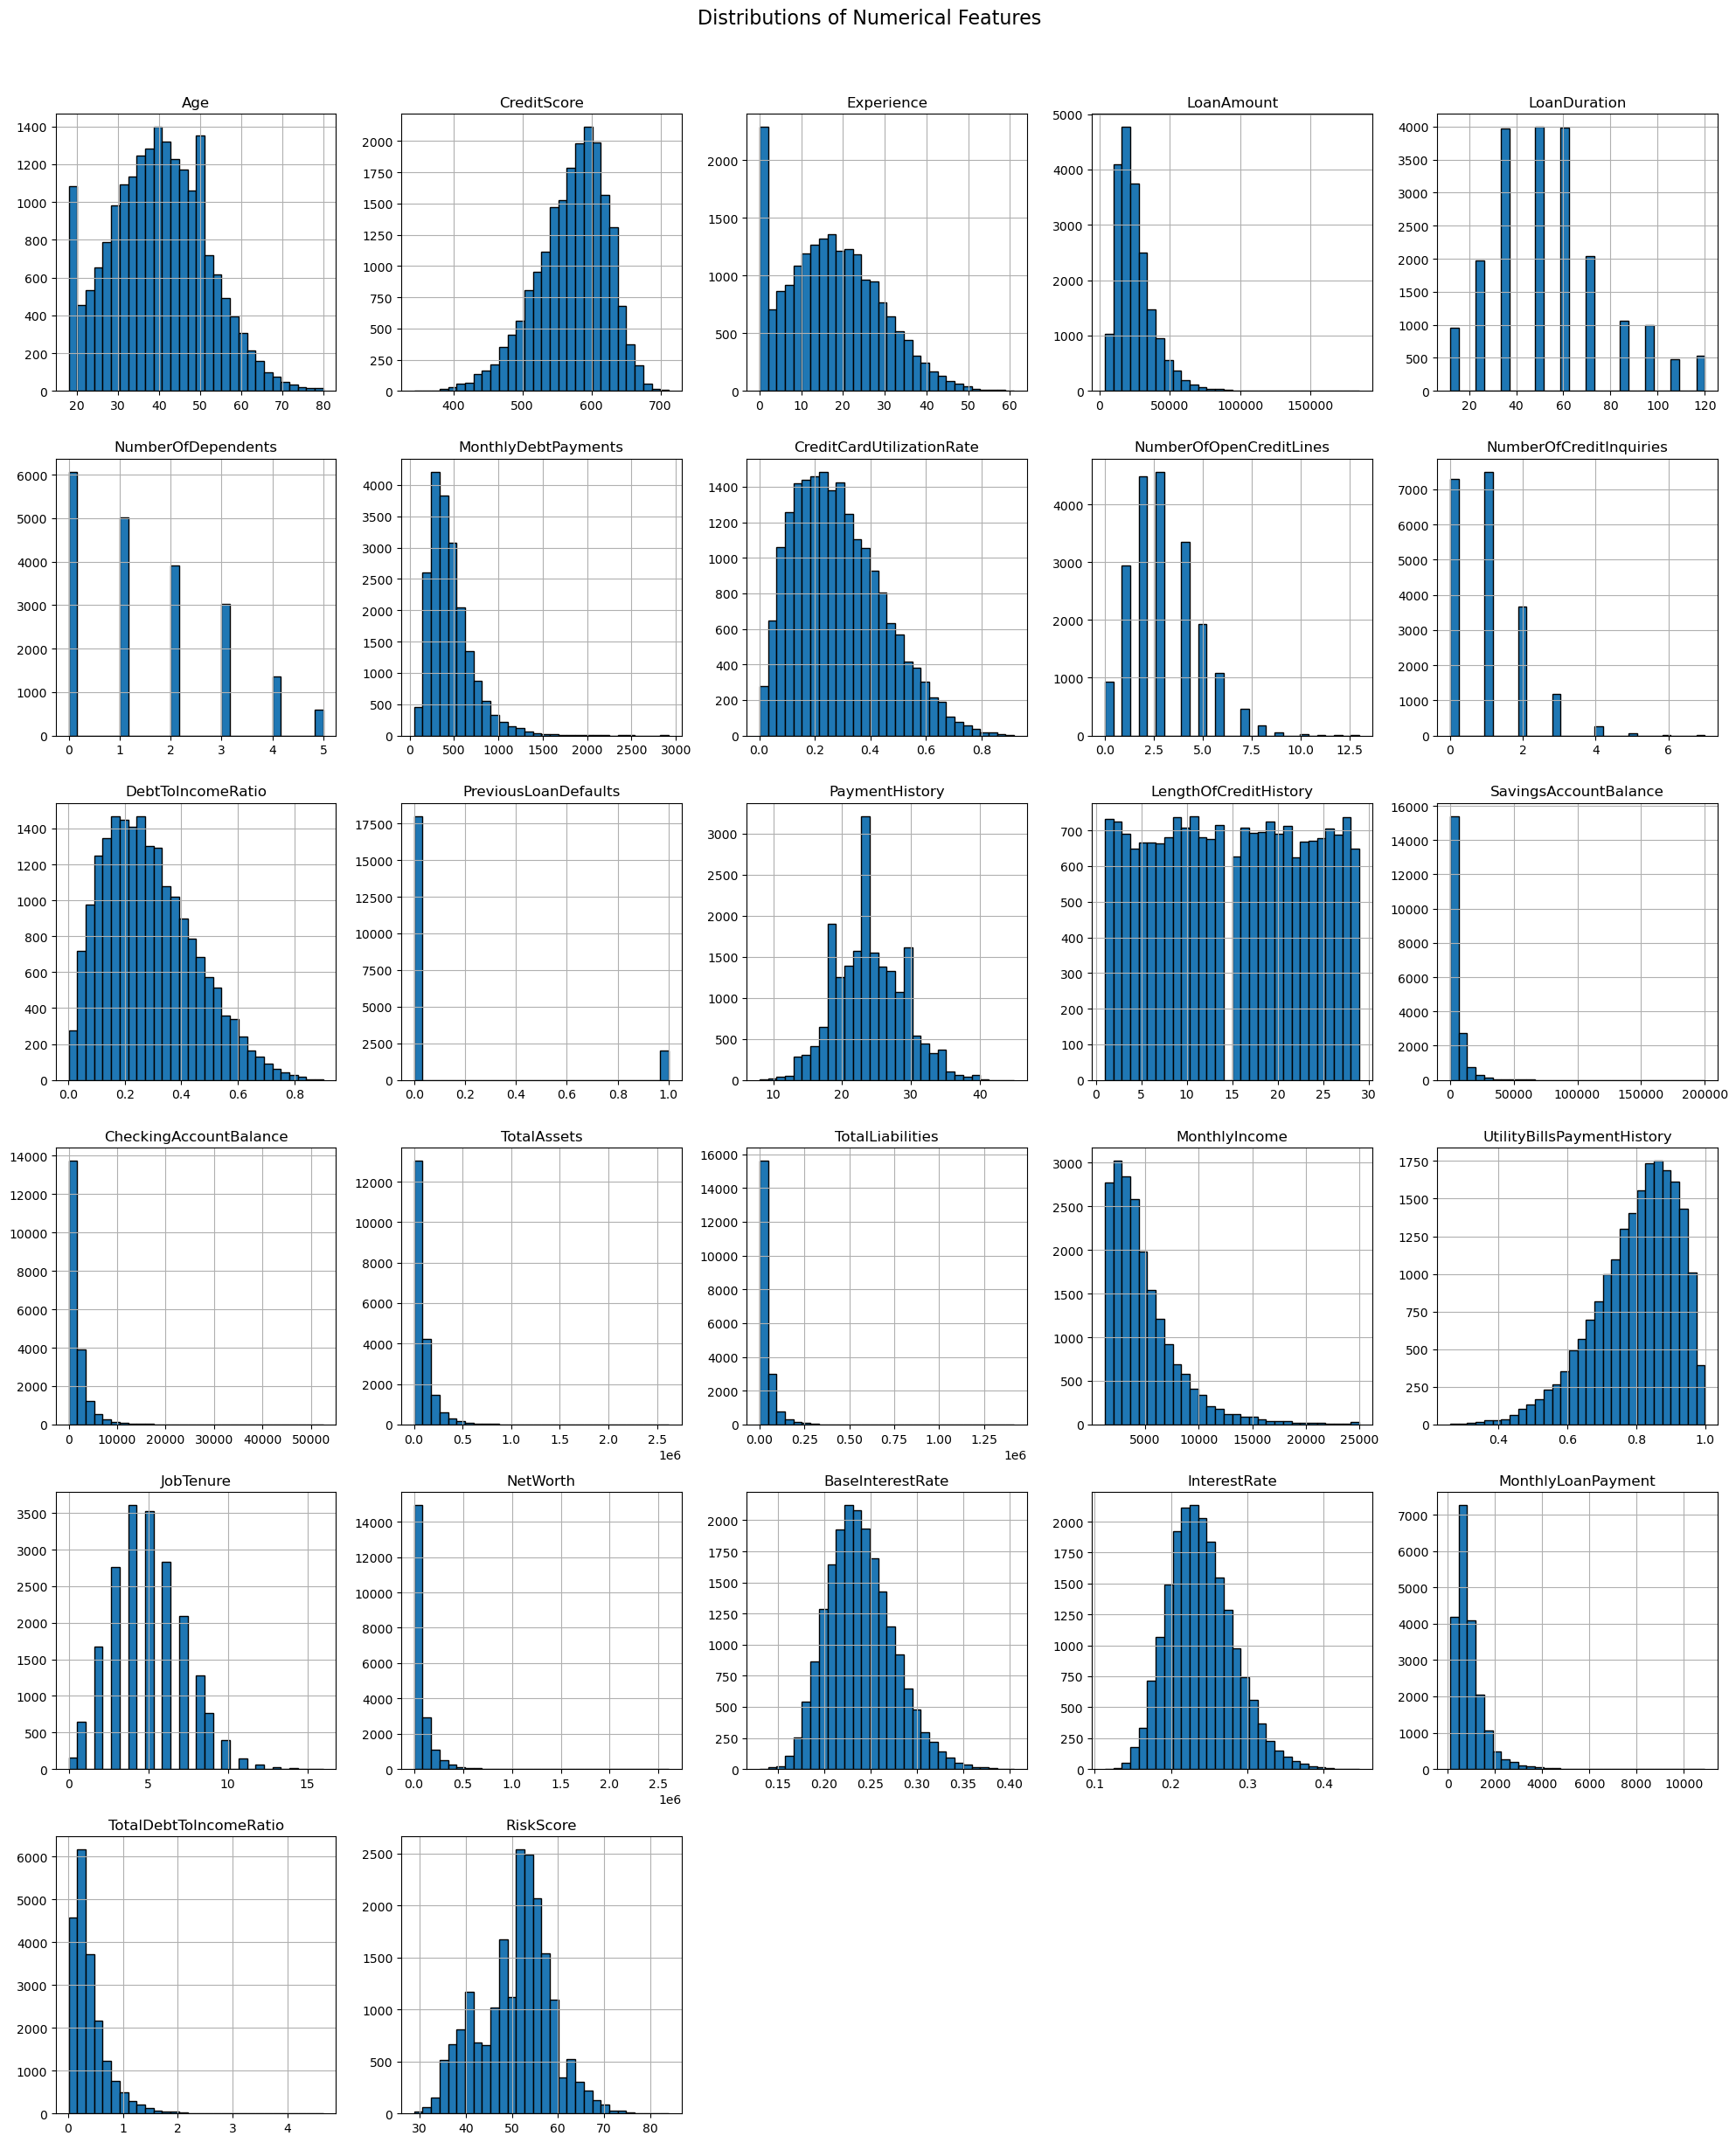

In [117]:
# plotting distributions of numerical features
df[numeric_cols].hist(
    figsize=(20, 24),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distributions of Numerical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>


The distributions of the numerical features were examined to identify skewness, unusual values, potential outliers, and differences in scale. 

Financial variables are expected to exhibit some degree of skewness because balances, income, assets, liabilities, and loan amounts can vary substantially between applicants. These distributions will help determine whether transformations, scaling, or additional investigation are required during data preparation

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.8. Categorical Feature Distribution
</h4>


In [118]:
categorical_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col != "AnnualIncome"
]

categorical_cols

['EmploymentStatus',
 'EducationLevel',
 'MaritalStatus',
 'HomeOwnershipStatus',
 'BankruptcyHistory',
 'LoanPurpose']

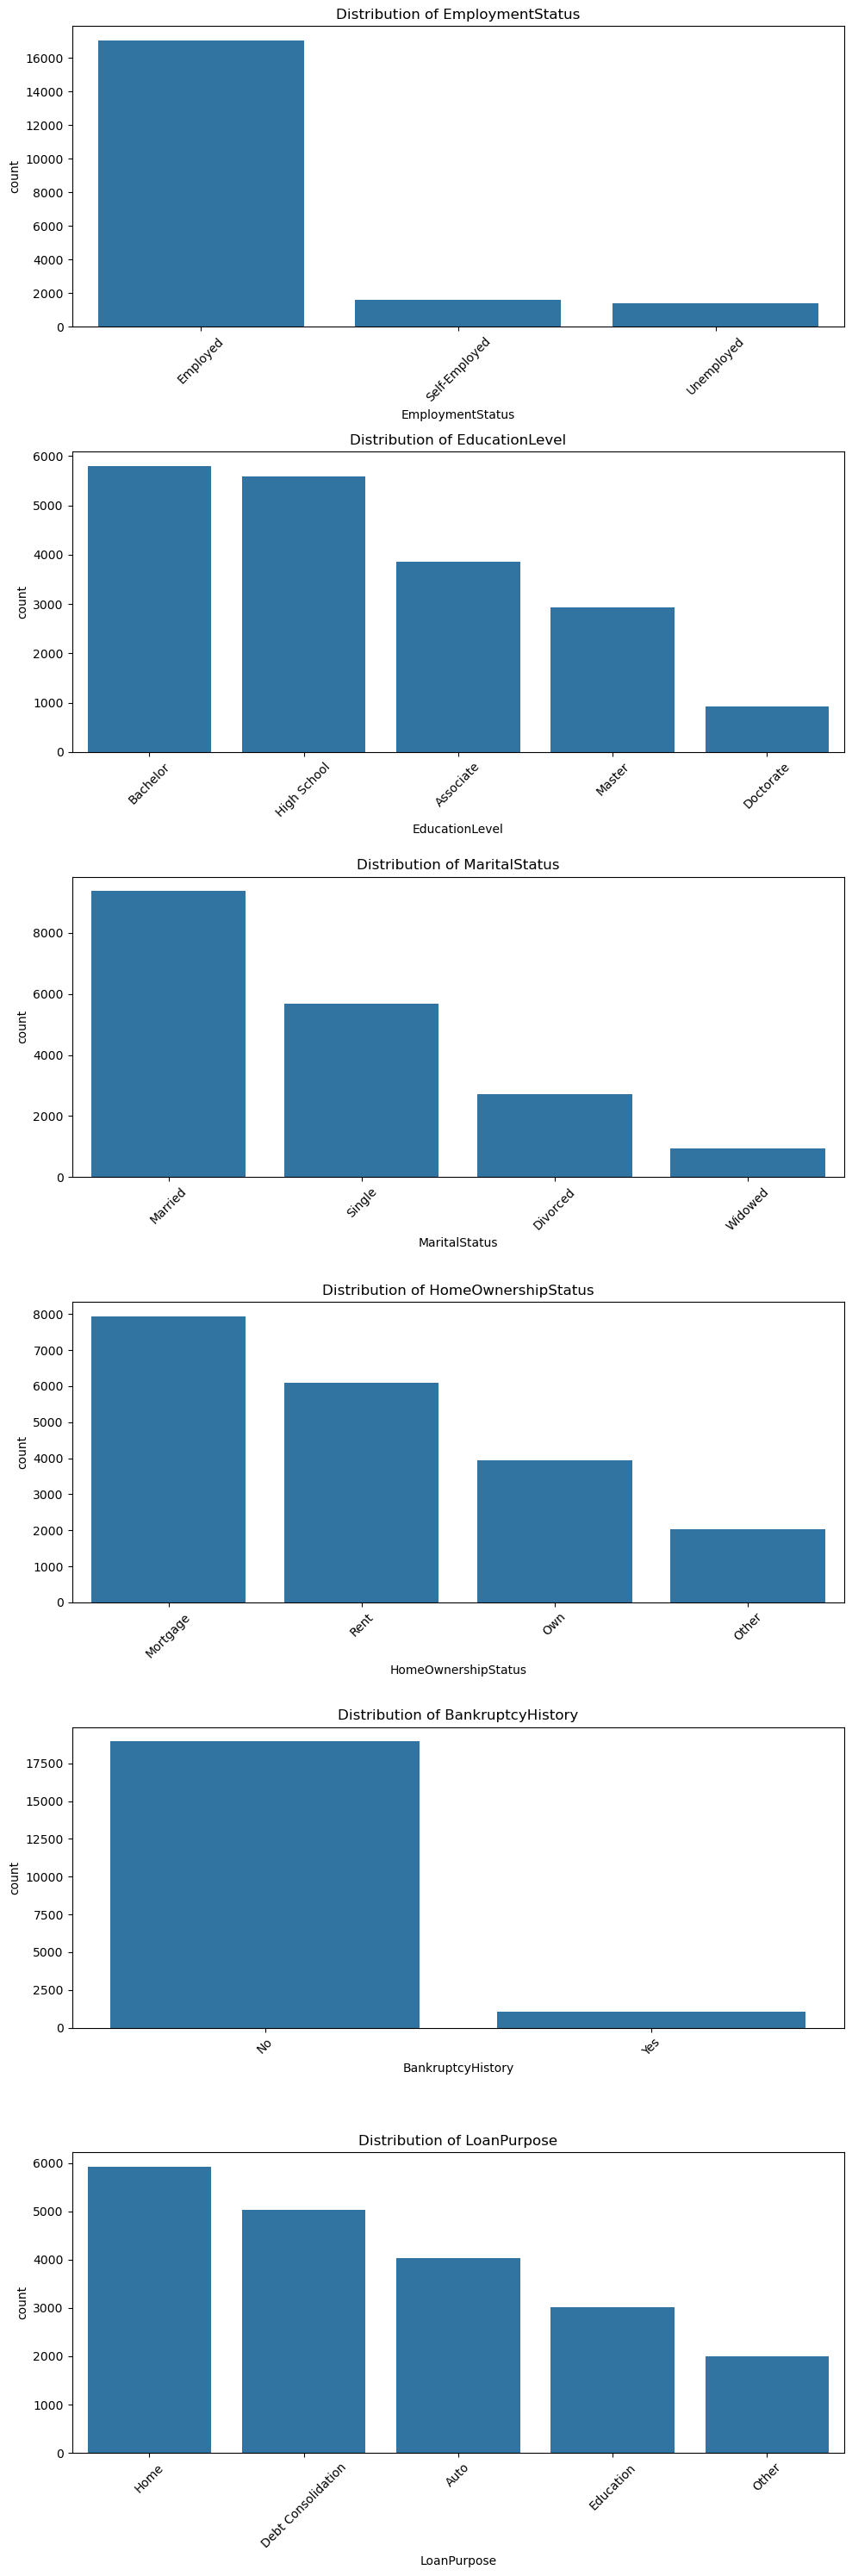

In [119]:
# visualizing the categorical distributions
fig, axes = plt.subplots(
    nrows=len(categorical_cols),
    ncols=1,
    figsize=(10, 5 * len(categorical_cols))
)

for ax, column in zip(axes, categorical_cols):
    sns.countplot(
        data=df,
        x=column,
        ax=ax,
        order=df[column].value_counts().index
    )
    
    ax.set_title(f"Distribution of {column}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.9. Potential Outliers Investigation
</h4>


In [120]:
continuous_features = [
    "Age",
    "CreditScore",
    "LoanAmount",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "DebtToIncomeRatio",
    "SavingsAccountBalance",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "MonthlyIncome",
    "NetWorth"
]

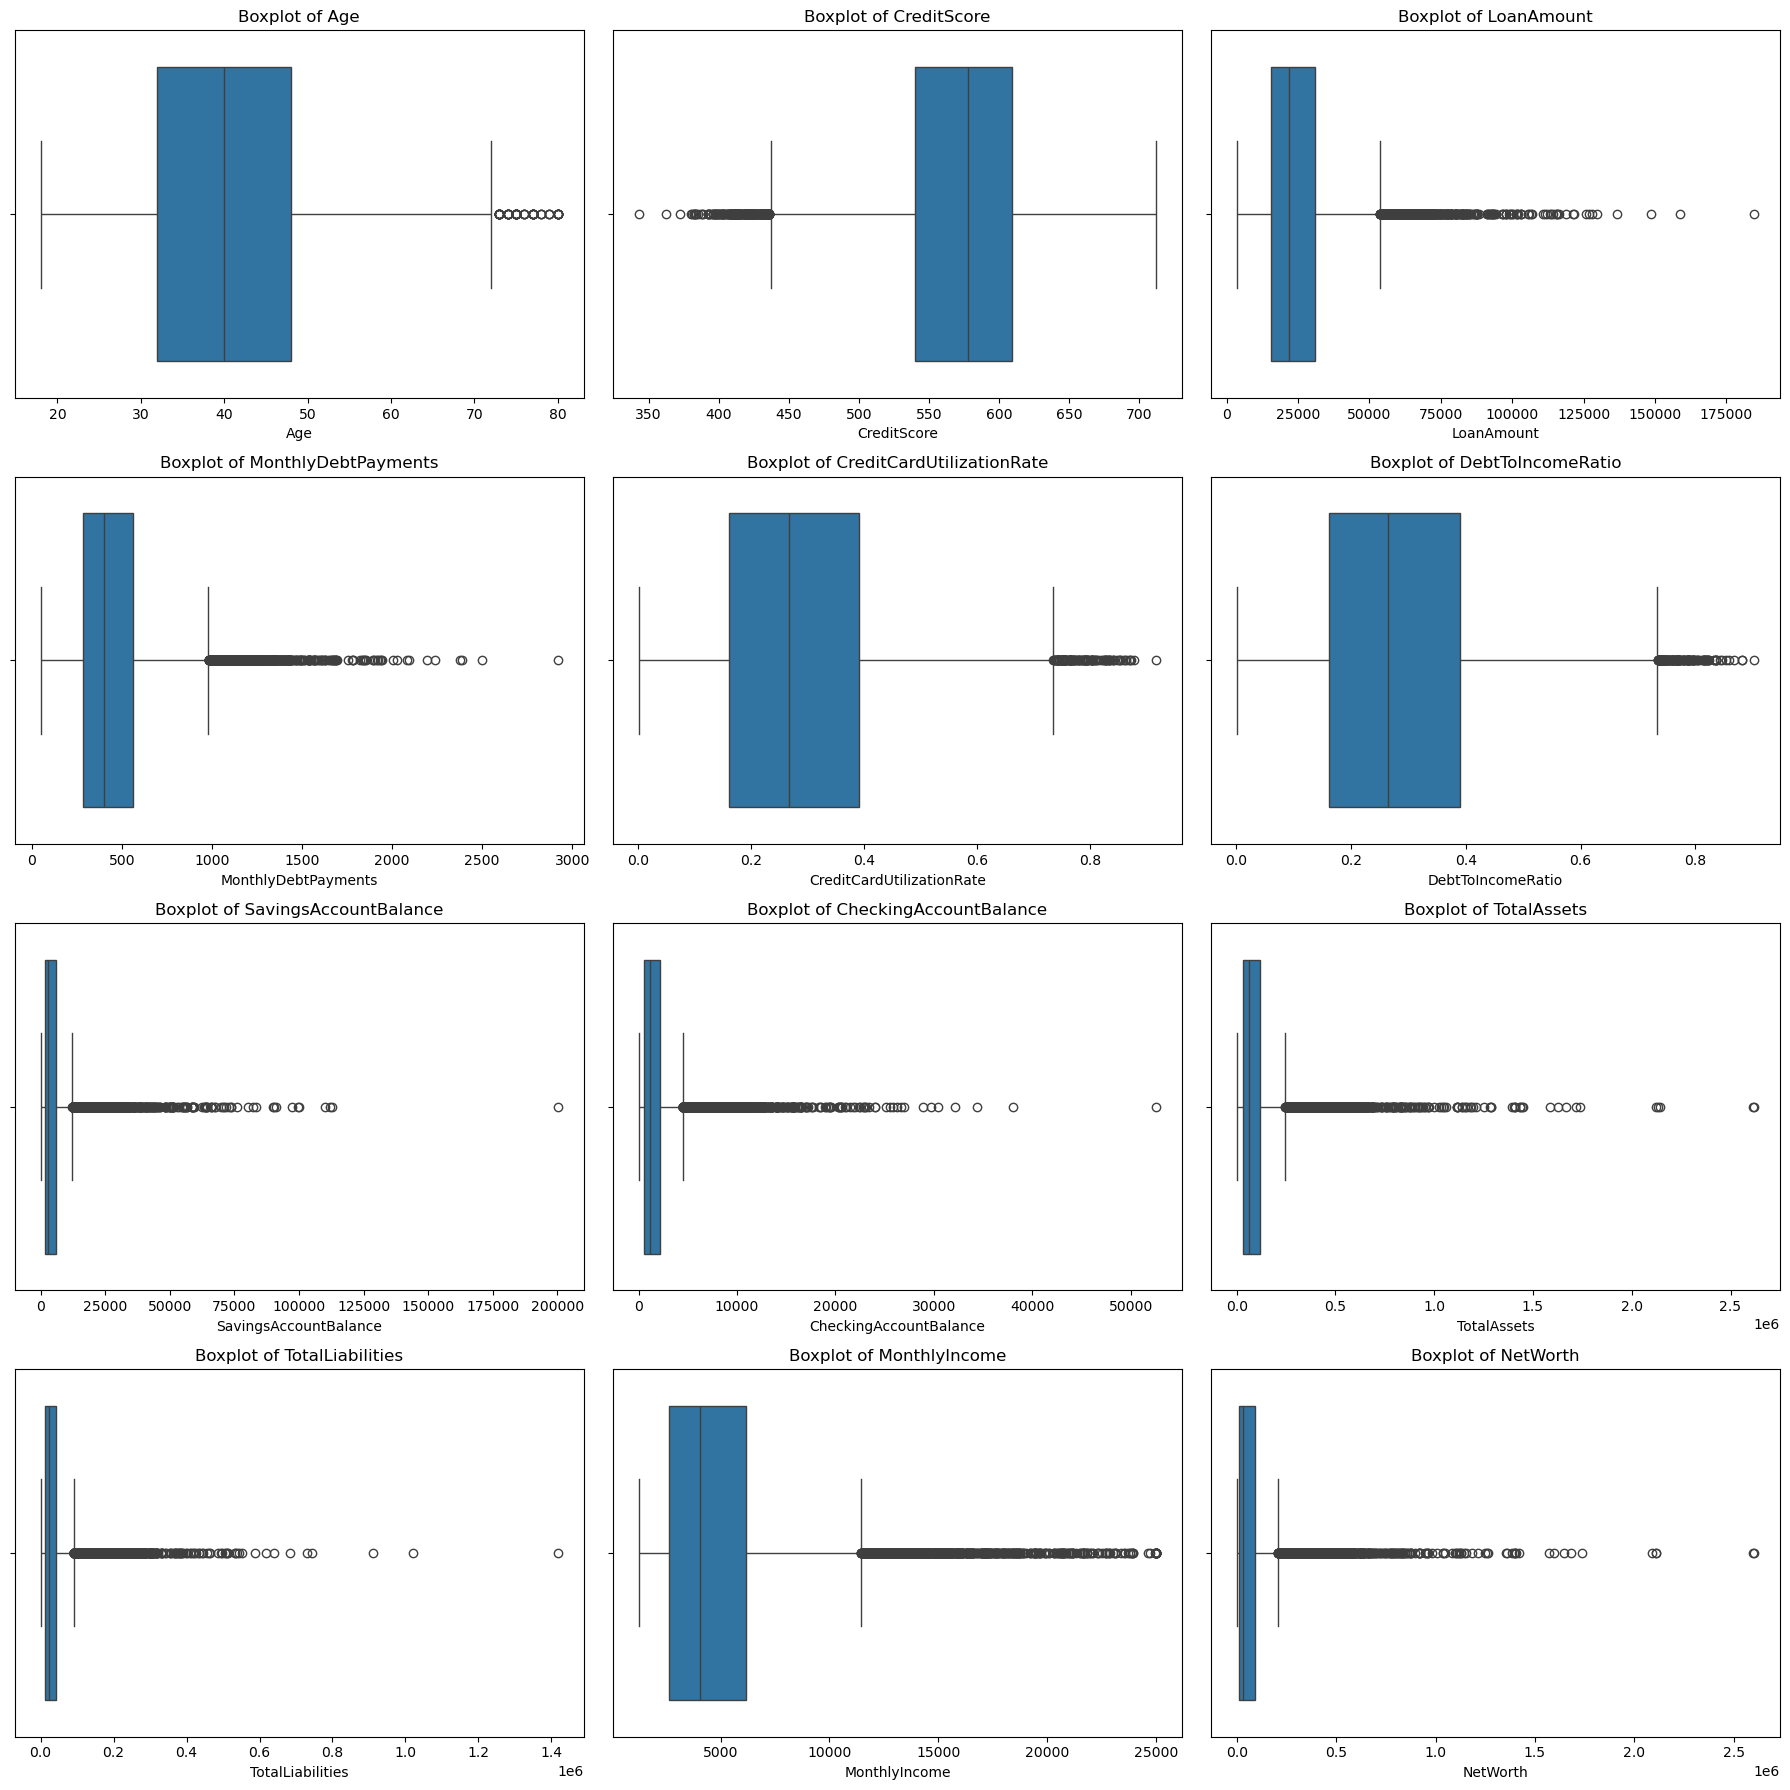

In [121]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(18, 18)
)

axes = axes.flatten()

for i, column in enumerate(continuous_features):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

Some financial variables may contain observations that appear as outliers in their boxplots. These observations will not be removed automatically because extreme financial values may represent legitimate applicants rather than data-entry errors. Their validity and potential influence on model performance will be considered during data preparation.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.10. Relationship between Numerical Features
</h4>


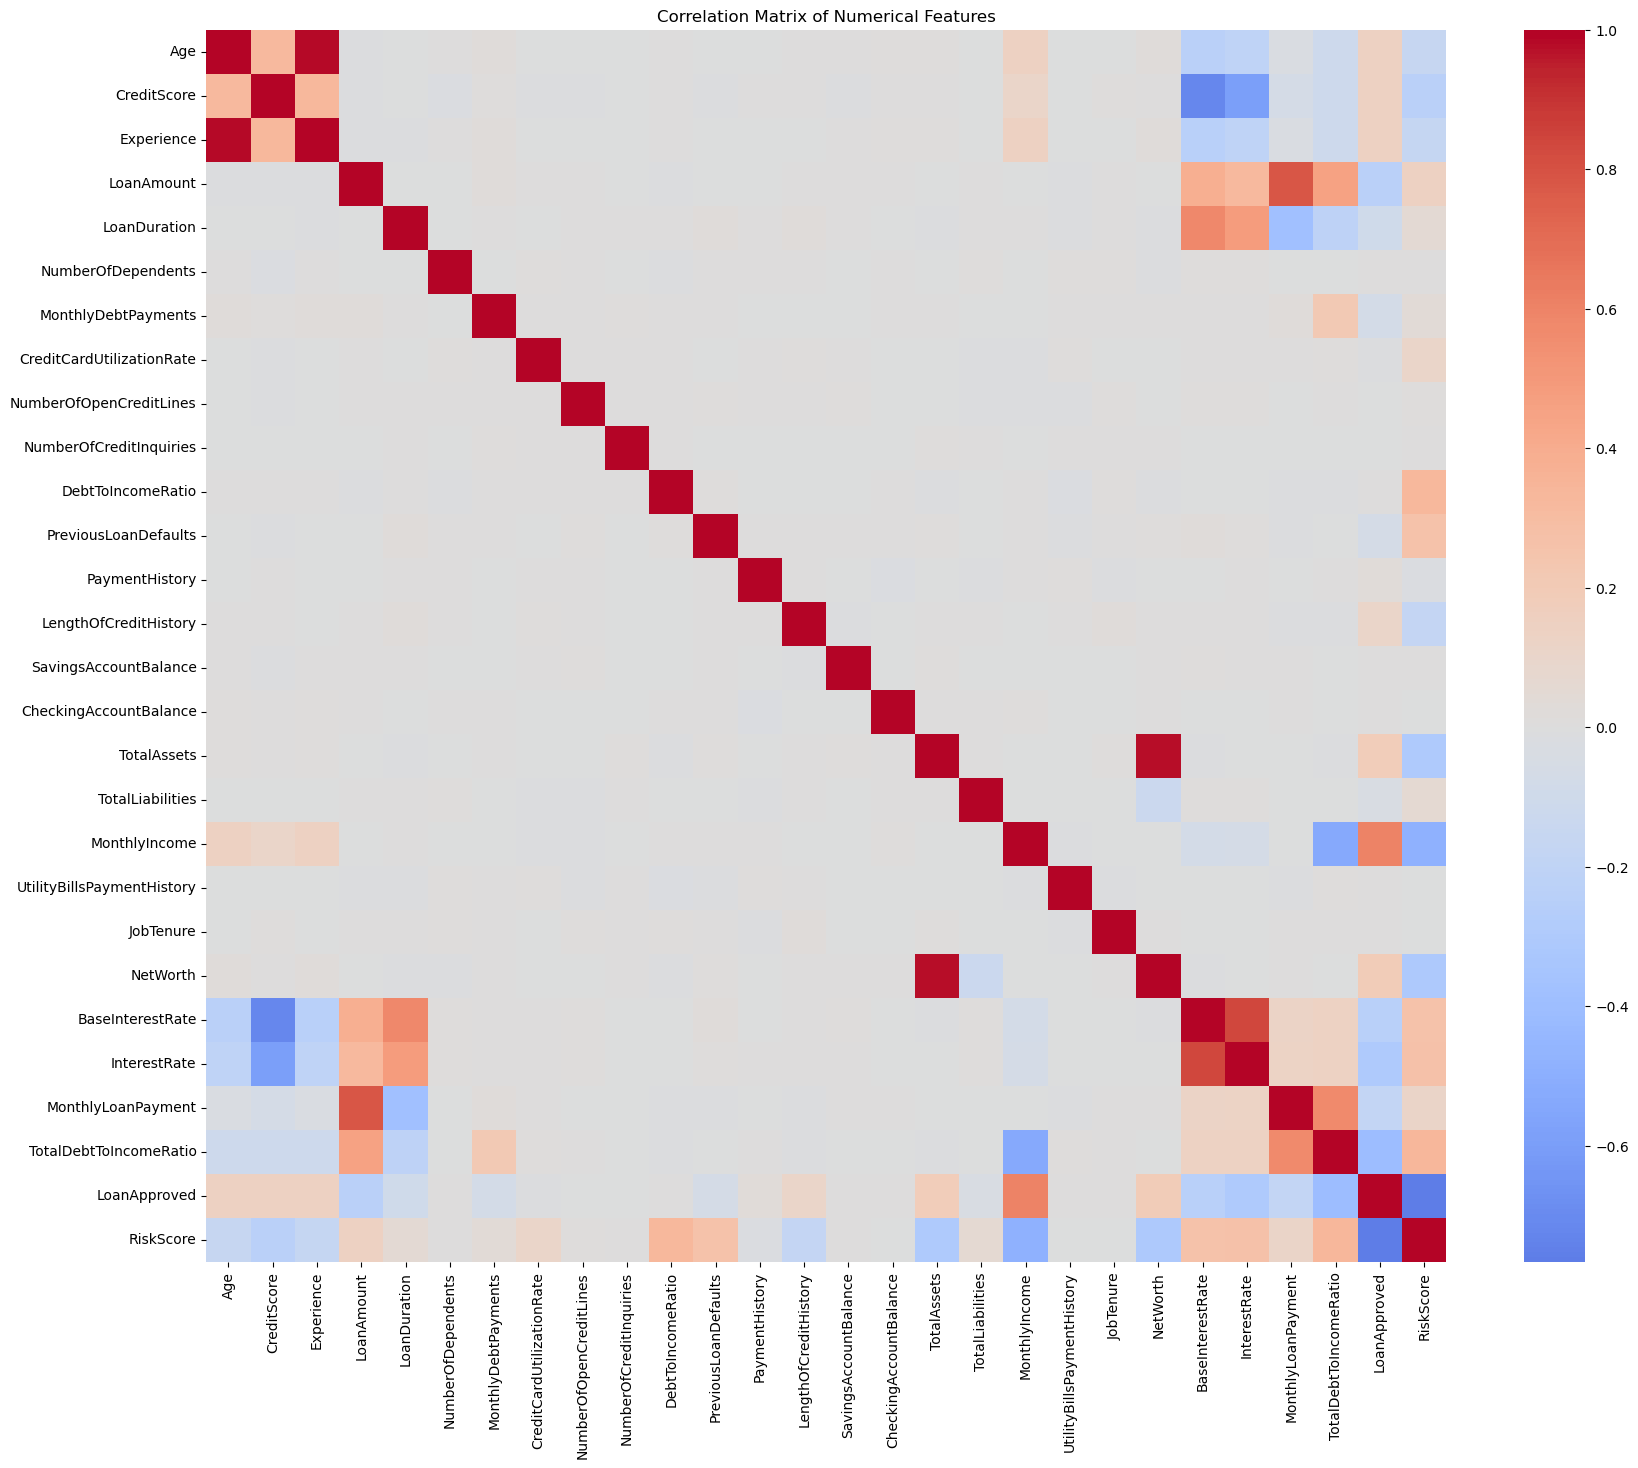

In [122]:
# correlation matrix for thee numerical variables
correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [123]:
# because of the more than 30 numerical variables and denseness we will examine the correlations with our target
target_correlations = (
    correlation_matrix["LoanApproved"]
    .drop("LoanApproved")
    .sort_values(ascending=False)
)

target_correlations

MonthlyIncome                 0.604101
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
PaymentHistory                0.030804
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
SavingsAccountBalance        -0.000258
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
LoanDuration                 -0.094558
MonthlyLoanPayment           -0.184272
LoanAmount                   -0.239496
BaseInterestRate             -0.247263
InterestRate                 -0.301646
TotalDebtToIncomeRatio   

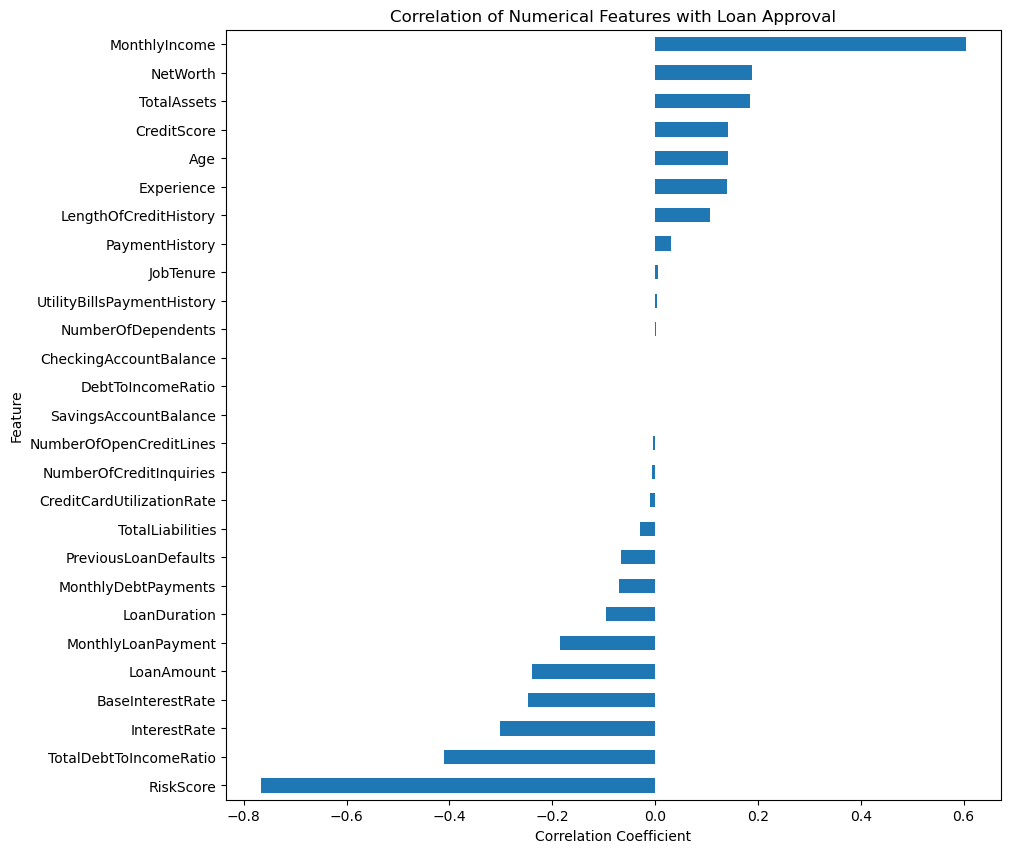

In [124]:
# and now we visualize them
plt.figure(figsize=(10, 10))

target_correlations.sort_values().plot(kind="barh")

plt.title("Correlation of Numerical Features with Loan Approval")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

The correlation analysis shows that several financial and credit-related features are associated with historical loan approval decisions. `MonthlyIncome` has the strongest positive correlation with `LoanApproved`, indicating that applicants with higher monthly income were more frequently represented among approved applications. `RiskScore` has the strongest negative correlation, suggesting that higher risk scores are strongly associated with denied applications.

`TotalDebtToIncomeRatio`, `InterestRate`, `BaseInterestRate`, and `LoanAmount` also show negative relationships with approval, while `NetWorth`, `TotalAssets`, `CreditScore`, `Age`, and `Experience` show positive relationships of varying strength.

These correlations describe associations rather than causal relationships. Features with weak linear correlations may still provide useful predictive information through nonlinear relationships or interactions with other variables.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.11. Numerical Features vs Loan Approval
</h4>


In [125]:
key_numeric_features = [
    "CreditScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "MonthlyIncome",
    "NetWorth",
    "RiskScore"
]

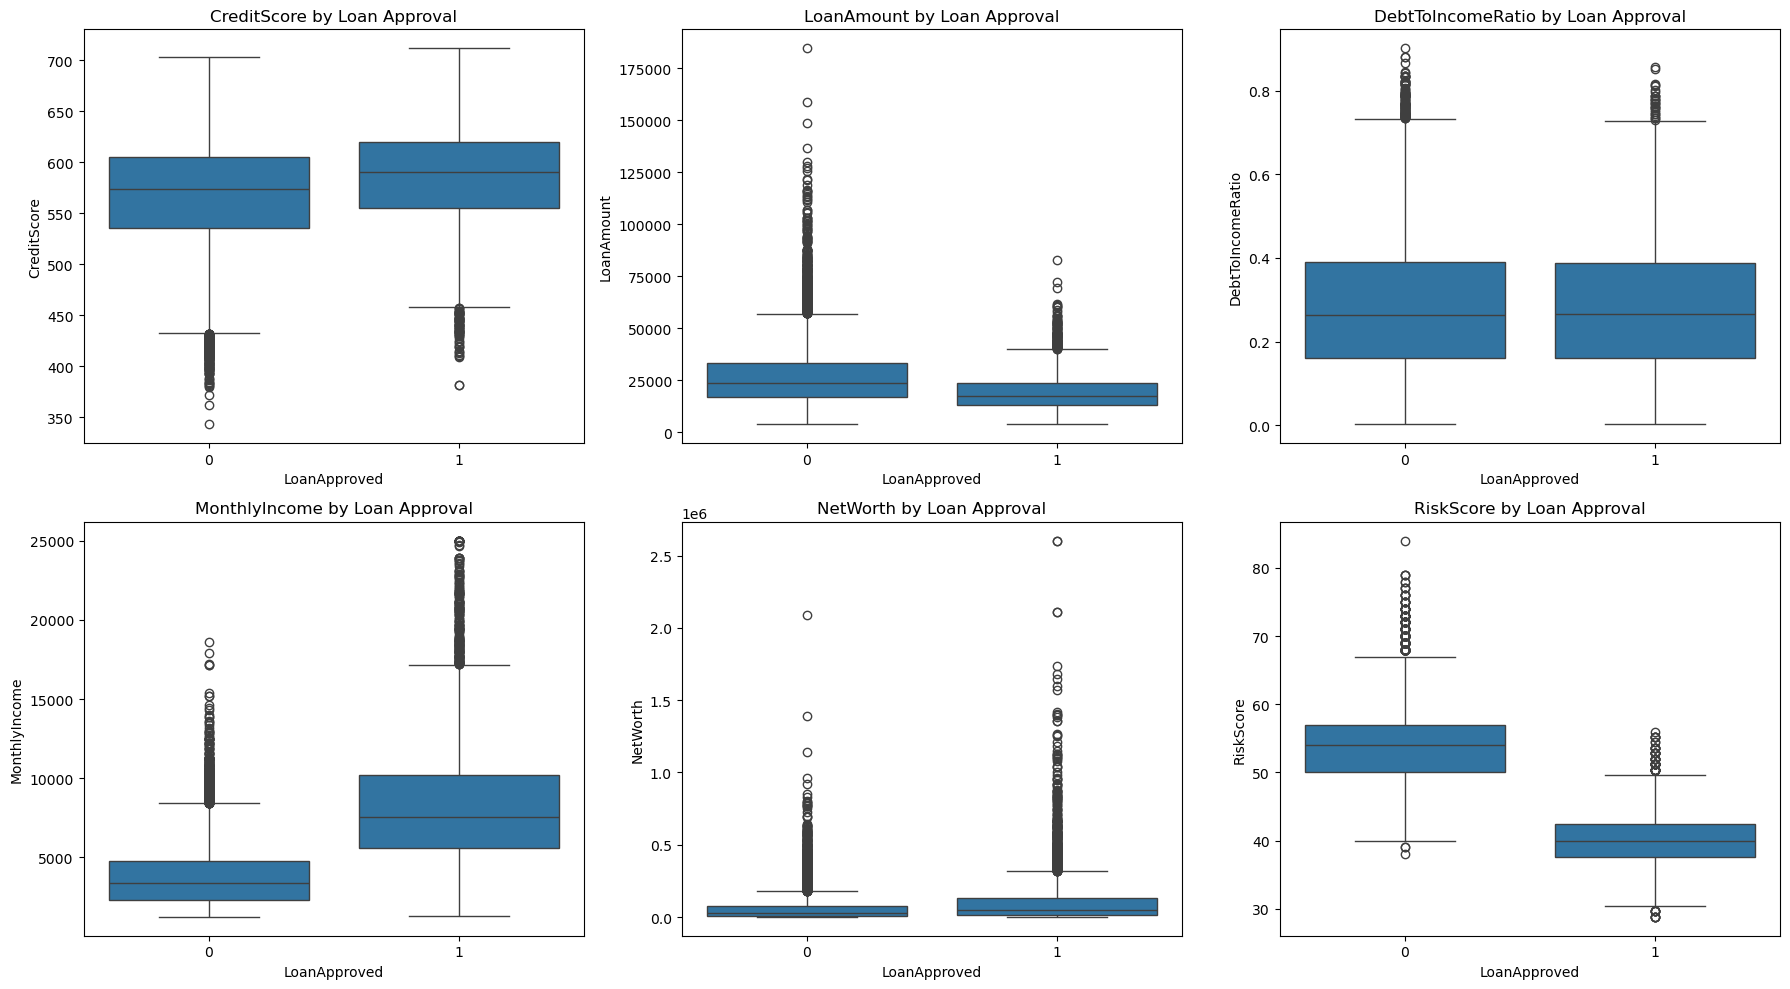

In [126]:
# we use boxplots to visualize this
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

for i, column in enumerate(key_numeric_features):
    sns.boxplot(
        data=df,
        x="LoanApproved",
        y=column,
        ax=axes[i]
    )

    axes[i].set_title(f"{column} by Loan Approval")

plt.tight_layout()
plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Observation
</h4>

The boxplots provide additional evidence of differences between approved and denied applications. Approved applicants generally have higher `MonthlyIncome` and somewhat higher `CreditScore` and `NetWorth`, while their `LoanAmount` tends to be lower. However, considerable overlap exists between the two groups for several variables, indicating that individual features alone are unlikely to explain all approval decisions.

`DebtToIncomeRatio` shows very similar distributions across the two approval groups, whereas `TotalDebtToIncomeRatio` showed a considerably stronger negative correlation with loan approval. This difference warrants further investigation during feature selection and preprocessing.

Several financial variables, particularly `NetWorth` and `LoanAmount`, also contain extreme observations. These values should not automatically be removed because they may represent legitimate applicants, but their influence on model performance should be considered.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.12. Categorical Features vs Loan Approval
</h4>


In [127]:
employment_approval = pd.crosstab(
    df["EmploymentStatus"],
    df["LoanApproved"],
    normalize="index"
) * 100

employment_approval

LoanApproved,0,1
EmploymentStatus,,
Employed,75.997887,24.002113
Self-Employed,72.155118,27.844882
Unemployed,81.811646,18.188354


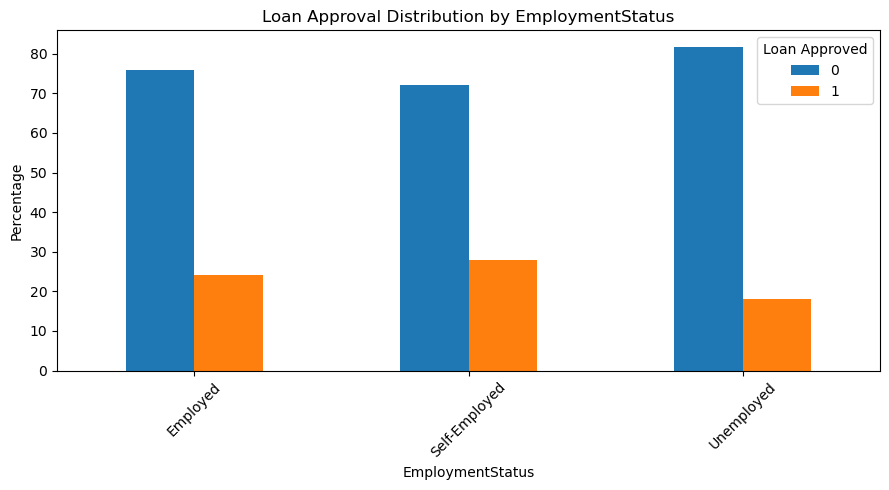

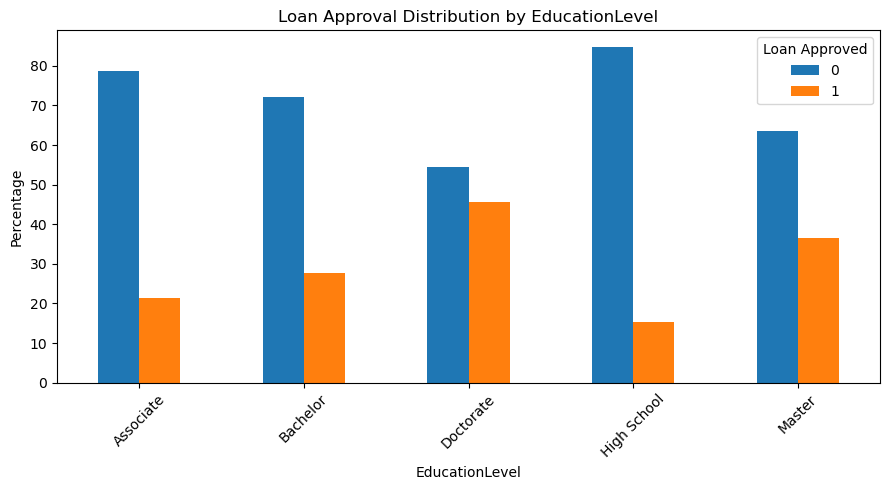

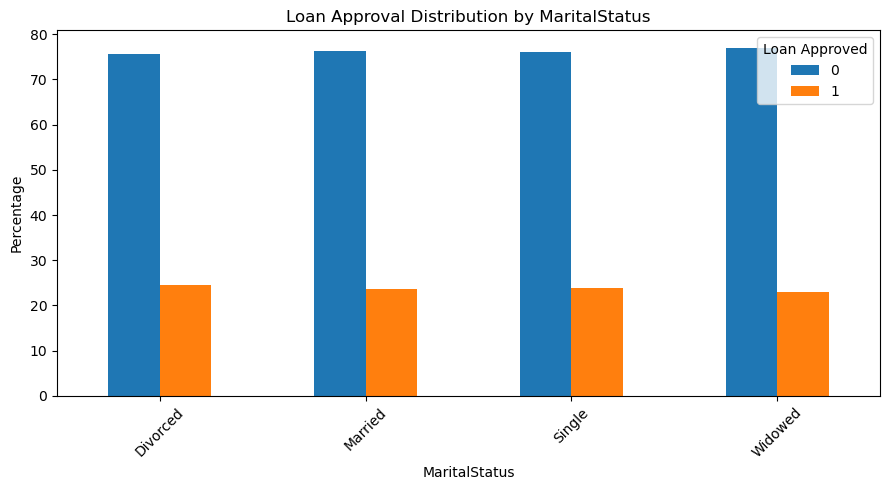

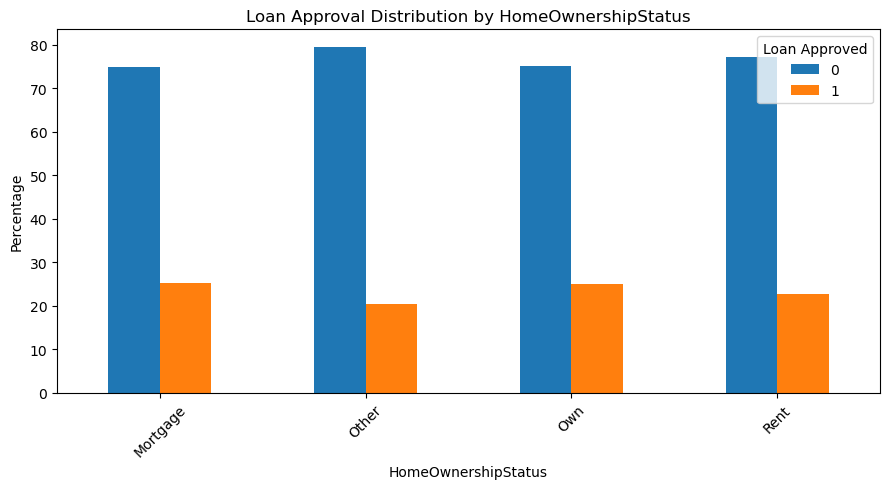

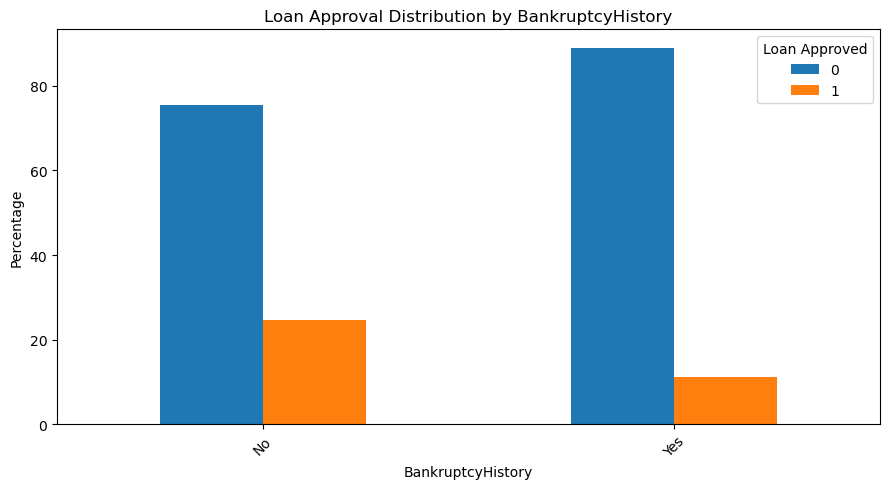

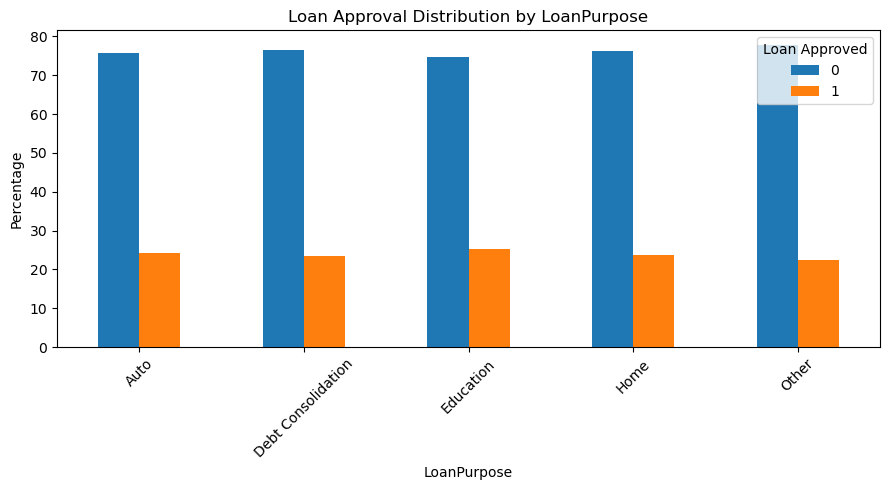

In [128]:
for column in categorical_cols:

    approval_rate = pd.crosstab(
        df[column],
        df["LoanApproved"],
        normalize="index"
    ) * 100

    approval_rate.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(f"Loan Approval Distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Loan Approved")
    plt.tight_layout()
    plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.13. Missing Values Patterns
</h4>

In [129]:
# we shouldnt assume missing values appear randomly, we check whether it relates to loan approval
missing_cols = [
    "MaritalStatus",
    "EducationLevel",
    "SavingsAccountBalance"
]

for column in missing_cols:
    missing_flag = df[column].isnull()

    print(f"\n{column}")
    print(
        pd.crosstab(
            missing_flag,
            df["LoanApproved"],
            normalize="index"
        ) * 100
    )


MaritalStatus
LoanApproved           0          1
MaritalStatus                      
False          76.142268  23.857732
True           75.507137  24.492863

EducationLevel
LoanApproved             0          1
EducationLevel                       
False            74.972512  25.027488
True            100.000000   0.000000

SavingsAccountBalance
LoanApproved                   0          1
SavingsAccountBalance                      
False                  76.173564  23.826436
True                   73.601399  26.398601


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.14. Potential Feature Engineering Opportunities
</h4>

Initial exploration suggests a number of opportunities that may be considered during data preparation:

- `AnnualIncome` should be converted from currency format to a numerical variable.
- Income, debt, assets, liabilities, and loan amount may provide useful relative measures rather than only absolute values.
- Existing variables such as debt-to-income ratios should be examined before creating additional ratio-based features to avoid unnecessary duplication.
- Highly correlated financial features may introduce redundant information and should be investigated before modeling.
- Numerical features with substantially different scales may require scaling for models such as logistic regression.
- Missing values in categorical and numerical variables will require appropriate imputation strategies.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
2.14. Data Understanding Summary
</h4>

The exploratory analysis identified several considerations that will influence the data preparation and modeling stages:

- The dataset contains 20,000 observations and includes numerical, categorical, binary, and potentially ordinal features.
- The target variable is imbalanced, with substantially fewer approved applications than denied applications.
- `AnnualIncome` requires conversion from a currency-formatted string to a numerical representation.
- Missing values occur in `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance` and will require appropriate treatment.
- Several financial variables contain potentially extreme observations that require consideration rather than automatic removal.
- Numerical features operate on substantially different scales.
- Relationships between several financial and credit characteristics and historical loan approval are visible in the exploratory analysis.
- Some variables require further investigation for potential redundancy or data leakage before modeling.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Data Leakage Assessment
</h4>

The exploratory analysis identified `RiskScore` as having an unusually strong negative relationship with `LoanApproved`. Review showed that `RiskScore` is calculated after the loan approval outcome and is directly adjusted using `LoanApproved`.

Because this means that `RiskScore` contains information derived from the target variable, including it as a predictor would introduce target leakage and could lead to unrealistically strong model performance. Therefore, `RiskScore` will be excluded from the feature set used to predict `LoanApproved`.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Dataset Limitation
</h4>

The supplied data-generation script indicates that the loan dataset is synthetic. Applicant characteristics were generated using statistical distributions and predefined relationships, while loan approval outcomes were created using a programmed decision rule.

This makes the dataset useful for demonstrating the machine learning workflow, but model performance should not be interpreted as evidence that the model would achieve the same results on real-world lending data. Real applicants may exhibit more complex patterns, changing economic conditions, measurement errors, and forms of bias that are not fully represented by synthetic data.

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
3. Data Preparation
</h3>

This section prepares the dataset for machine learning based on the issues identified during exploratory analysis

The process includes correcting data types, separating predictors from the target, removing features that introduce target leakage, splitting the data into training and testing sets, handling missing values, encoding categorical variables, and scaling numerical features where appropriate.

In [130]:
# Create a copy for preprocessing
model_df = df.copy()

model_df.shape

(20000, 35)

In [131]:
# we inspect annual income and convert it
model_df["AnnualIncome"].head()

0     $39,948.00
1     $39,709.00
2     $40,724.00
3     $69,084.00
4    $103,264.00
Name: AnnualIncome, dtype: object

In [132]:
model_df["AnnualIncome"] = (
    model_df["AnnualIncome"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [133]:
# we verify the change
model_df["AnnualIncome"].dtype

dtype('float64')

In [134]:
model_df["AnnualIncome"].head()

0     39948.0
1     39709.0
2     40724.0
3     69084.0
4    103264.0
Name: AnnualIncome, dtype: float64

`AnnualIncome` was converted from a currency-formatted string to a numerical variable by removing the dollar sign and comma separators. This allows the variable to be used correctly in numerical preprocessing and machine learning models.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.1. Remove Leakage
</h4>

In [135]:
model_df = model_df.drop(columns=["RiskScore"])

In [136]:
"RiskScore" in model_df.columns

False

`RiskScore` was excluded from the modeling dataset because the data-generation process confirmed that it was calculated using `LoanApproved`. Retaining it would introduce target leakage.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.2. Define X and y
</h4>

In [137]:
X = model_df.drop(columns=["LoanApproved"])
y = model_df["LoanApproved"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (20000, 33)
Target: (20000,)


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.3. Train-Test Split
</h4>

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [140]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 33)
X_test: (4000, 33)
y_train: (16000,)
y_test: (4000,)


In [141]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64

Testing target distribution:
LoanApproved
0    0.761
1    0.239
Name: proportion, dtype: float64


The data was split into training and testing sets before fitting preprocessing transformations. An 80/20 split was used, with stratification to preserve the class distribution of `LoanApproved` in both datasets.

Preprocessing parameters such as imputation values and scaling statistics will be learned only from the training data. This prevents information from the test set from influencing the model-development process and reduces the risk of data leakage.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.4. Build Preprocessing Pipeline
</h4>

In [142]:
# Identify numerical and categorical features
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

print("\nCategorical features:")
print(categorical_features)

Numerical features: 27
Categorical features: 6

Categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.4. Numerical Preprocessing
</h4>

We have two main issues;

- SavingsAccountBalance contains missing values.
- Numerical features have very different scales.

For financial data such as savings balances, the distribution can be skewed and contain large values. The median is less affected by extreme observations than the mean.

In [143]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.5. Categorical Preprocessing
</h4>

We have missing values in categorical features such as:

- EducationLevel
- MaritalStatus

In [144]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.6. Combine both Transformations
</h4>

A `ColumnTransformer` is used to apply different preprocessing operations to numerical and categorical features. This approach keeps preprocessing within the ML workflow and ensures that transformations are learned from the training data rather than from the full dataset, thus reducing the risk of data leakage

In [145]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.7. Establish the Baseline Model
</h4>

Because we already know the majority class is approximately 76%. We now formally establish it

In [146]:
# imports
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [147]:
# baseline creation
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

In [148]:
# baseline evaluation
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print(f"Baseline Accuracy:  {baseline_accuracy:.3f}")
print(f"Baseline Precision: {baseline_precision:.3f}")
print(f"Baseline Recall:    {baseline_recall:.3f}")
print(f"Baseline F1 Score:  {baseline_f1:.3f}")

Baseline Accuracy:  0.761
Baseline Precision: 0.000
Baseline Recall:    0.000
Baseline F1 Score:  0.000


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.8. Baseline Confusion Matrix
</h4>

In [149]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_predictions
)

baseline_cm

array([[3044,    0],
       [ 956,    0]], dtype=int64)

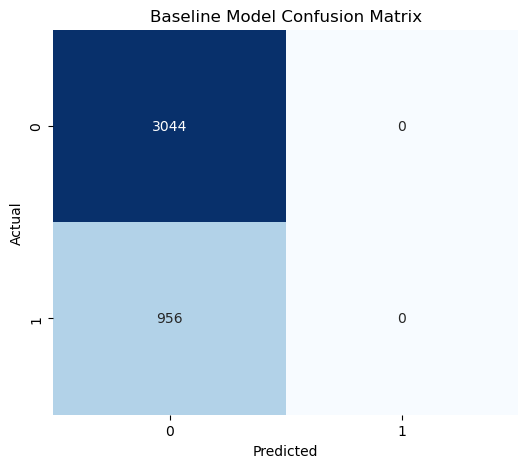

In [150]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Baseline Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
3.9. Custom Business-Cost Metric Creation
</h4>

In [151]:
def business_cost(y_true, y_pred):
    """
    Calculate the estimated financial cost of classification errors.

    False Positive:
        Approving a loan that should not be approved = $50,000

    False Negative:
        Denying a creditworthy applicant = $8,000
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    total_cost = (fp * 50000) + (fn * 8000)

    return total_cost

In [152]:
baseline_cost = business_cost(
    y_test,
    baseline_predictions
)

print(f"Baseline Estimated Business Cost: ${baseline_cost:,.0f}")

Baseline Estimated Business Cost: $7,648,000


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Baseline Performance
</h4>

A majority-class `DummyClassifier` was used to establish baseline performance. Because most historical applications were denied, the baseline predicts the majority class for every observation.

Although this strategy achieves relatively high accuracy because of the class imbalance, it fails to identify approved applications, resulting in zero recall and F1-score for the positive class. This demonstrates why accuracy alone is unsuitable for evaluating the models in this project.

The baseline also provides a reference business cost based on the estimated $50,000 cost of a false approval and $8,000 opportunity cost of a false denial. Candidate models should improve upon both the predictive performance and estimated financial impact of this baseline.

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
4. Modeling
</h3>


This section develops and compares classification models for predicting `LoanApproved`. The models are trained using the preprocessing pipeline developed in the previous section to ensure that missing-value imputation, categorical encoding, and numerical scaling are performed consistently without introducing data leakage

Logistic Regression is used as the first candidate model because it provides an interpretable classification baseline. More flexible tree-based models will subsequently be developed and compared against both Logistic Regression and the majority-class baseline

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.1. Logistic Regression
</h4>

In [153]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [154]:
# Training
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [157]:
# We also want predicted probabilities because we'll need them for ROC-AUC and later threshold analysis
# Predicted classes
logistic_predictions = logistic_model.predict(X_test)

# Predicted probability of class 1
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.2. Logistic Regression Evaluation
</h4>

In [158]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

logistic_cost = business_cost(
    y_test,
    logistic_predictions
)

print(f"Accuracy:      {logistic_accuracy:.3f}")
print(f"Precision:     {logistic_precision:.3f}")
print(f"Recall:        {logistic_recall:.3f}")
print(f"F1 Score:      {logistic_f1:.3f}")
print(f"ROC-AUC:       {logistic_roc_auc:.3f}")
print(f"Business Cost: ${logistic_cost:,.0f}")

Accuracy:      0.965
Precision:     0.929
Recall:        0.924
F1 Score:      0.927
ROC-AUC:       0.995
Business Cost: $3,934,000


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.3. Classification Report
</h4>

In [159]:
print(
    classification_report(
        y_test,
        logistic_predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.92      0.93       956

    accuracy                           0.96      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.96      0.96      0.96      4000



<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.4. Confusion Matrix
</h4>

In [160]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

logistic_cm

array([[2977,   67],
       [  73,  883]], dtype=int64)

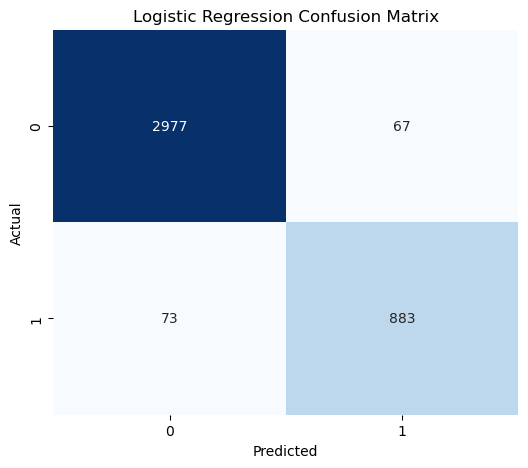

In [161]:
# Visulize it
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.5. Comparison Against the Baseline
</h4>

In [162]:
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy
    ],
    
    "Precision": [
        baseline_precision,
        logistic_precision
    ],
    
    "Recall": [
        baseline_recall,
        logistic_recall
    ],
    
    "F1 Score": [
        baseline_f1,
        logistic_f1
    ],
    
    "ROC-AUC": [
        np.nan,
        logistic_roc_auc
    ],
    
    "Business Cost": [
        baseline_cost,
        logistic_cost
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Business Cost
0,Dummy Classifier,0.761,0.000000,0.00000,0.000000,NaN,7648000
1,Logistic Regression,0.965,0.929474,0.92364,0.926548,0.994609,3934000


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.6. ROC Curve
</h4>

In [163]:
from sklearn.metrics import RocCurveDisplay

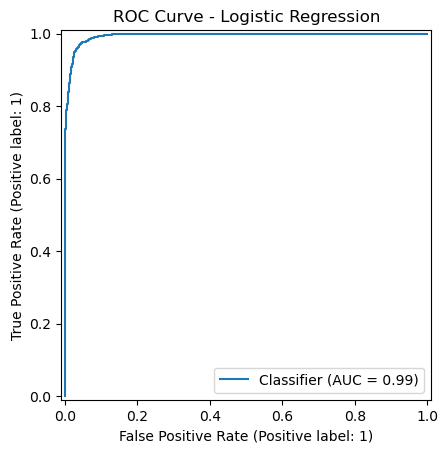

In [164]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.7. Interpretability: Logistic Regression Coefficients
</h4>

In [165]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [166]:
coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

In [167]:
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [168]:
coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df.head(10)

,Feature,Coefficient
19,num__MonthlyIncome,4.371270
43,cat__BankruptcyHistory_No,2.994862
32,cat__EducationLevel_Doctorate,2.529080
22,num__NetWorth,2.502048
14,num__LengthOfCreditHistory,1.672593
34,cat__EducationLevel_Master,1.210087
28,cat__EmploymentStatus_Self-Employed,1.122082
27,cat__EmploymentStatus_Employed,0.756908
1,num__AnnualIncome,0.521199
39,cat__HomeOwnershipStatus_Mortgage,0.516099


In [169]:
coefficient_df.tail(10)

,Feature,Coefficient
42,cat__HomeOwnershipStatus_Rent,-0.653380
12,num__PreviousLoanDefaults,-1.198716
30,cat__EducationLevel_Associate,-1.227575
2,num__CreditScore,-2.052209
29,cat__EmploymentStatus_Unemployed,-2.164413
4,num__LoanAmount,-2.172023
33,cat__EducationLevel_High School,-2.489805
44,cat__BankruptcyHistory_Yes,-3.280286
24,num__InterestRate,-5.182244
26,num__TotalDebtToIncomeRatio,-8.092212


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.8. Visualization of Important Coefficients
</h4>

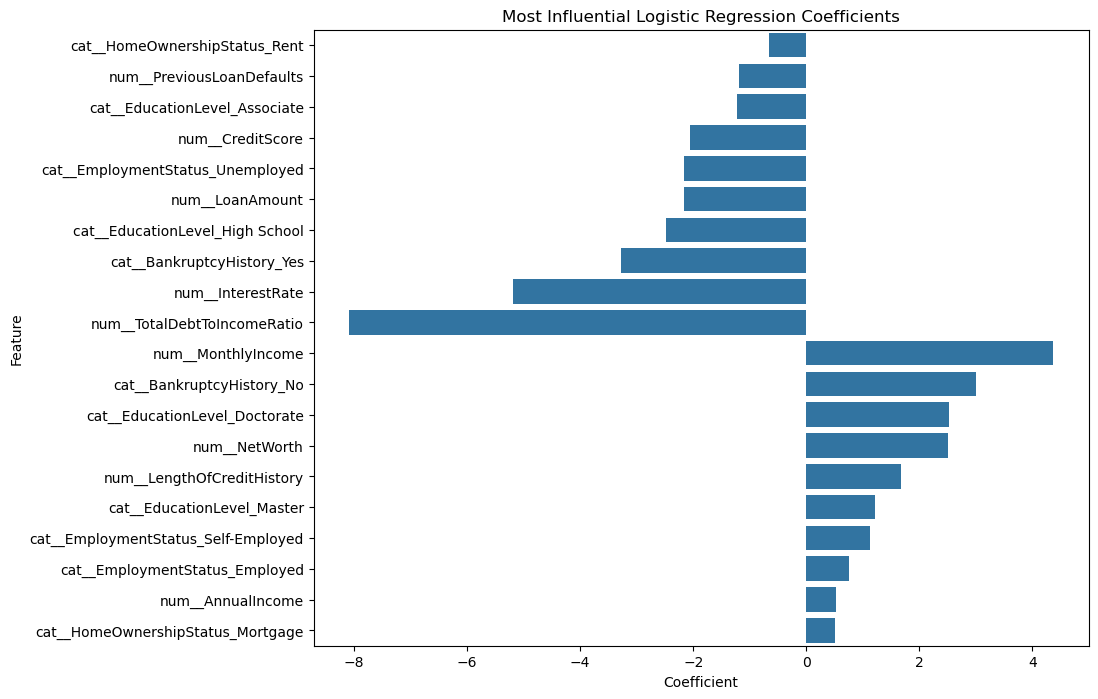

In [170]:
top_positive = coefficient_df.head(10)
top_negative = coefficient_df.tail(10)

important_coefficients = pd.concat([
    top_negative,
    top_positive
])

plt.figure(figsize=(10, 8))

sns.barplot(
    data=important_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Most Influential Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Logistic Regression Results
</h4>

The Logistic Regression model achieved an accuracy of 96.5%, precision of 92.9%, recall of 92.4%, an F1-score of 92.7%, and a ROC-AUC of 0.995. These results indicate that the model provides strong discrimination between historically approved and denied loan applications and substantially improves upon the majority-class baseline

The confusion matrix shows that the model correctly classified 2,977 denied applications and 883 approved applications. It incorrectly approved 67 applications that were historically denied (false positives) and incorrectly denied 73 applications that were historically approved (false negatives)

Using the estimated business costs defined earlier, these errors correspond to an estimated total cost of $3,934,000. False positives contribute $3,350,000 of this amount, while false negatives contribute $584,000. Therefore, false approvals account for the majority of the model's estimated financial cost

Although the predictive performance is strong at the default 0.50 classification threshold, the asymmetric costs of the two error types suggest that the default threshold may not provide the lowest-cost business decision rule. Threshold optimization will therefore be considered after candidate models have been compared

The very high ROC-AUC should also be interpreted in the context of the synthetic nature of the dataset and its programmed approval relationships; equivalent performance should not be assumed for real-world lending data

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.9. Decision Tree
</h4>

A Decision Tree classifier is developed as the second candidate model. Unlike Logistic Regression, a Decision Tree can capture nonlinear relationships and interactions between applicant characteristics without assuming a linear relationship between the predictors and the log-odds of approval. 

Decision Trees are also relatively interpretable because their predictions can be represented as a sequence of decision rules.

In [171]:
# build the model
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [172]:
# making predictions
decision_tree_predictions = decision_tree_model.predict(X_test)

decision_tree_probabilities = decision_tree_model.predict_proba(
    X_test
)[:, 1]

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.10. Evaluate the Decision Tree
</h4>

In [173]:
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

decision_tree_precision = precision_score(
    y_test,
    decision_tree_predictions
)

decision_tree_recall = recall_score(
    y_test,
    decision_tree_predictions
)

decision_tree_f1 = f1_score(
    y_test,
    decision_tree_predictions
)

decision_tree_roc_auc = roc_auc_score(
    y_test,
    decision_tree_probabilities
)

decision_tree_cost = business_cost(
    y_test,
    decision_tree_predictions
)

print(f"Accuracy:      {decision_tree_accuracy:.3f}")
print(f"Precision:     {decision_tree_precision:.3f}")
print(f"Recall:        {decision_tree_recall:.3f}")
print(f"F1 Score:      {decision_tree_f1:.3f}")
print(f"ROC-AUC:       {decision_tree_roc_auc:.3f}")
print(f"Business Cost: ${decision_tree_cost:,.0f}")

Accuracy:      0.887
Precision:     0.758
Recall:        0.774
F1 Score:      0.766
ROC-AUC:       0.848
Business Cost: $13,528,000


In [174]:
print(
    classification_report(
        y_test,
        decision_tree_predictions
    )
)

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3044
           1       0.76      0.77      0.77       956

    accuracy                           0.89      4000
   macro avg       0.84      0.85      0.85      4000
weighted avg       0.89      0.89      0.89      4000



<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.11. Decision Tree Confusion Matrix
</h4>

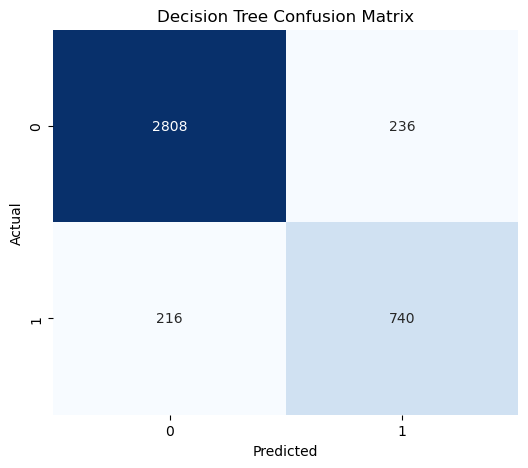

In [175]:
decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.12. Overfitting Check
</h4>

This is important for Decision Trees, a completely unrestricted tree can effectively keep splitting until it fits the training data extremely closely.

In [176]:
# training accuracy calculation
decision_tree_train_accuracy = decision_tree_model.score(
    X_train,
    y_train
)

decision_tree_test_accuracy = decision_tree_model.score(
    X_test,
    y_test
)

print(
    f"Training Accuracy: {decision_tree_train_accuracy:.3f}"
)

print(
    f"Testing Accuracy:  {decision_tree_test_accuracy:.3f}"
)

Training Accuracy: 1.000
Testing Accuracy:  0.887


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.13. Adding Decision Tree to Comparison
</h4>

In [177]:
decision_tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [decision_tree_accuracy],
    "Precision": [decision_tree_precision],
    "Recall": [decision_tree_recall],
    "F1 Score": [decision_tree_f1],
    "ROC-AUC": [decision_tree_roc_auc],
    "Business Cost": [decision_tree_cost]
})

model_comparison = pd.concat(
    [model_comparison, decision_tree_results],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Business Cost
0,Dummy Classifier,0.761,0.000000,0.000000,0.000000,NaN,7648000
1,Logistic Regression,0.965,0.929474,0.923640,0.926548,0.994609,3934000
2,Decision Tree,0.887,0.758197,0.774059,0.766046,0.848265,13528000


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Decision Tree Results
</h4>

The Decision Tree achieved an accuracy of 88.7%, precision of 75.8%, recall of 77.4%, an F1-score of 76.6%, and a ROC-AUC of 0.848. Its predictive performance was therefore substantially weaker than the Logistic Regression model.

The confusion matrix shows that the Decision Tree correctly classified 2,808 denied applications and 740 approved applications. However, it produced 236 false positives and 216 false negatives. Under the defined business-cost assumptions, these errors result in an estimated cost of $13,528,000.

The increase in false positives is particularly important because each false approval carries an estimated cost of $50,000. False positives alone account for $11,800,000 of the Decision Tree's estimated error cost. In comparison, Logistic Regression produced only 67 false positives and an overall estimated cost of $3,934,000.

These results demonstrate that greater model flexibility does not necessarily lead to better generalization. The performance of the unrestricted Decision Tree also motivates the use of ensemble methods such as Random Forest, which combine multiple trees to produce more stable predictions.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.14. Random Forest
</h4>

A Random Forest classifier is developed as the third candidate model. Random Forest combines predictions from multiple Decision Trees, which can reduce the variance and overfitting associated with a single unrestricted tree. It can also capture nonlinear relationships and interactions between applicant characteristics

The initial Random Forest model is trained using largely default parameters to establish its untuned performance before hyperparameter optimization

In [181]:
# train the model
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['Age','AnnualIncome','CreditScore',...,'InterestRate', 'MonthlyLoanPayment','TotalDebtToIncomeRatio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

In [182]:
# make predictions
random_forest_predictions = random_forest_model.predict(X_test)

random_forest_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.15. Random Forest Evaluation
</h4>

In [183]:
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

random_forest_f1 = f1_score(
    y_test,
    random_forest_predictions
)

random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_probabilities
)

random_forest_cost = business_cost(
    y_test,
    random_forest_predictions
)

print(f"Accuracy:      {random_forest_accuracy:.3f}")
print(f"Precision:     {random_forest_precision:.3f}")
print(f"Recall:        {random_forest_recall:.3f}")
print(f"F1 Score:      {random_forest_f1:.3f}")
print(f"ROC-AUC:       {random_forest_roc_auc:.3f}")
print(f"Business Cost: ${random_forest_cost:,.0f}")

Accuracy:      0.932
Precision:     0.900
Recall:        0.808
F1 Score:      0.851
ROC-AUC:       0.978
Business Cost: $5,772,000


In [184]:
print(
    classification_report(
        y_test,
        random_forest_predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      3044
           1       0.90      0.81      0.85       956

    accuracy                           0.93      4000
   macro avg       0.92      0.89      0.90      4000
weighted avg       0.93      0.93      0.93      4000



<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.16. Random Forest Confusion Matrix
</h4>

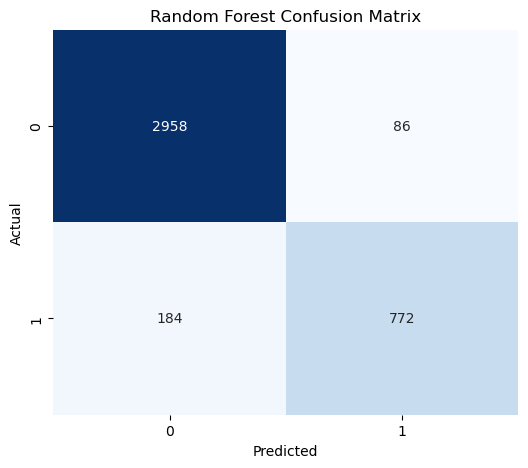

In [185]:
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.17. Training vs Testing Performance Check
</h4>

In [186]:
random_forest_train_accuracy = random_forest_model.score(
    X_train,
    y_train
)

random_forest_test_accuracy = random_forest_model.score(
    X_test,
    y_test
)

print(f"Training Accuracy: {random_forest_train_accuracy:.3f}")
print(f"Testing Accuracy:  {random_forest_test_accuracy:.3f}")

Training Accuracy: 1.000
Testing Accuracy:  0.932


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.18. Adding Random Forest to Comparison
</h4>

In [187]:
random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [random_forest_accuracy],
    "Precision": [random_forest_precision],
    "Recall": [random_forest_recall],
    "F1 Score": [random_forest_f1],
    "ROC-AUC": [random_forest_roc_auc],
    "Business Cost": [random_forest_cost]
})

model_comparison = pd.concat(
    [model_comparison, random_forest_results],
    ignore_index=True
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Business Cost
0,Dummy Classifier,0.7610,0.000000,0.000000,0.000000,NaN,7648000
1,Logistic Regression,0.9650,0.929474,0.923640,0.926548,0.994609,3934000
2,Decision Tree,0.8870,0.758197,0.774059,0.766046,0.848265,13528000
3,Random Forest,0.9325,0.899767,0.807531,0.851158,0.977754,5772000


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Random Forest Results
</h4>

The Random Forest achieved an accuracy of 93.2%, precision of 90.0%, recall of 80.8%, an F1-score of 85.1%, and a ROC-AUC of 0.978. This represents a substantial improvement over the single Decision Tree, demonstrating the benefit of combining multiple trees to produce more stable predictions

The confusion matrix shows 2,958 true negatives and 772 true positives, with 86 false positives and 184 false negatives. Based on the defined error costs, these misclassifications produce an estimated business cost of $5,772,000

The model achieved 100% accuracy on the training data compared with 93.2% on the test data. This gap suggests that the untuned Random Forest is overfitting the training data to some extent and may benefit from regularization through hyperparameter tuning

Despite outperforming the Decision Tree, the untuned Random Forest does not outperform Logistic Regression on the test set. Logistic Regression currently produces higher accuracy, precision, recall, F1-score and ROC-AUC while also generating the lowest estimated business cost. Further model validation and optimization are therefore required before selecting a final model

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
4.19. Initial Model Comparison
</h4>

In [188]:
model_comparison.sort_values(
    by="Business Cost"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Business Cost
1,Logistic Regression,0.9650,0.929474,0.923640,0.926548,0.994609,3934000
3,Random Forest,0.9325,0.899767,0.807531,0.851158,0.977754,5772000
0,Dummy Classifier,0.7610,0.000000,0.000000,0.000000,NaN,7648000
2,Decision Tree,0.8870,0.758197,0.774059,0.766046,0.848265,13528000


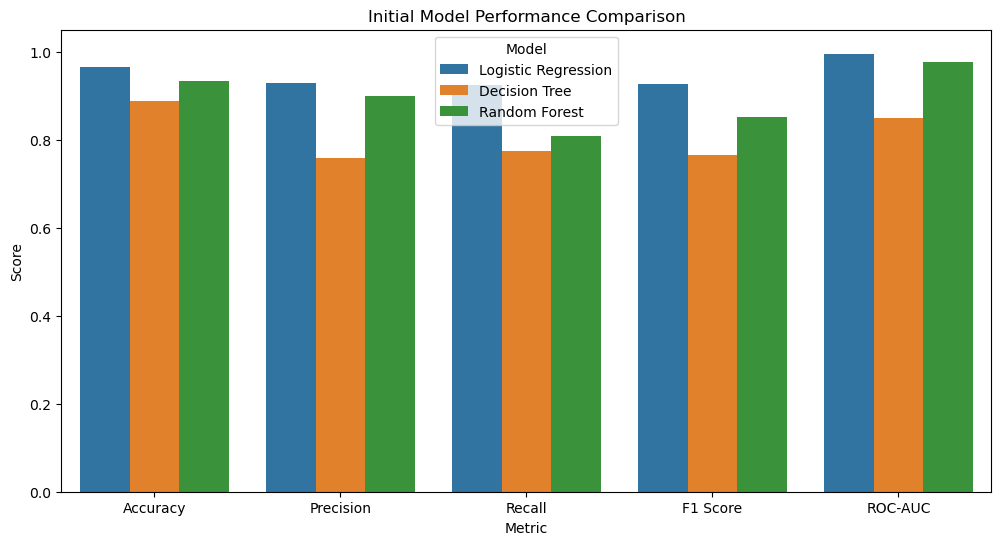

In [189]:
# visualizing the predictive metrics
comparison_plot = model_comparison[
    model_comparison["Model"] != "Dummy Classifier"
].copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_long = comparison_plot.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1.05)
plt.title("Initial Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")

plt.show()

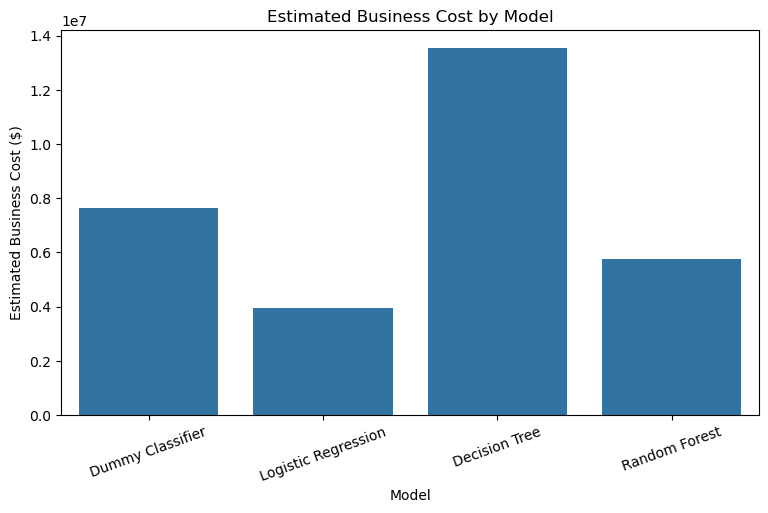

In [190]:
# business cost visualization
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Business Cost"
)

plt.title("Estimated Business Cost by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Business Cost ($)")
plt.xticks(rotation=20)

plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Initial Model Comparison
</h4>

Among the three initial machine learning models, Logistic Regression currently provides the strongest test-set performance. It achieves the highest predictive metrics while producing the lowest estimated business cost. The Decision Tree performs substantially worse, while Random Forest improves considerably upon the individual tree but remains behind Logistic Regression

The results also demonstrate why model selection should not rely on accuracy alone. Because false positives carry a substantially greater estimated financial cost than false negatives, the number and type of classification errors have direct business implications

These results represent initial holdout-set performance rather than final model selection. Cross-validation and model optimization will next be used to assess whether performance is stable across different subsets of the training data and whether the tree-based models can be improved through regularization and hyperparameter tuning

<h3 style= "color: #F4C300;; text-align: left; font-weight: bold;">
5. Model Optimization
</h3>

Following the initial model comparison, Logistic Regression was selected for optimization because it achieved the strongest overall predictive performance and the lowest estimated business cost among the candidate models

Hyperparameter tuning is performed using `GridSearchCV`. The search focuses on the regularization parameter `C` and class weighting. `C` controls the strength of regularization, while `class_weight` allows the model to account for the imbalance between approved and denied applications

A relatively small parameter grid is used to keep the optimization computationally efficient while still evaluating meaningful alternative model configurations

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
5.1. Parameter Grid Definition
</h4>

In [191]:
param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
5.2. GridSearchCV
</h4>

In [192]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t

In [193]:
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation F1: {grid_search.best_score_:.3f}")

Best Parameters: {'classifier__C': 10, 'classifier__class_weight': None}
Best Cross-Validation F1: 0.922


<h4 style= "color: #008000; text-align: left; font-weight: bold;">
5.3. Track parameter combinations
</h4>

In [194]:
tuning_results = pd.DataFrame(
    grid_search.cv_results_
)

tuning_summary = tuning_results[[
    "param_classifier__C",
    "param_classifier__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

tuning_summary

,param_classifier__C,param_classifier__class_weight,mean_train_score,mean_test_score,std_test_score,rank_test_score
4,10.0,None,0.929628,0.922190,0.006060,1
2,1.0,None,0.927463,0.921922,0.006915,2
0,0.1,None,0.921202,0.916758,0.012023,3
5,10.0,balanced,0.920282,0.916057,0.003911,4
3,1.0,balanced,0.918140,0.913267,0.006631,5
1,0.1,balanced,0.908491,0.904612,0.007566,6


The GridSearchCV results are examined across all tested parameter combinations rather than considering only the highest-scoring configuration. Training and cross-validation scores help assess whether changes in regularization and class weighting improve generalization or introduce unnecessary complexity.

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
5.4. Optimized Model Evaluation
</h4>

In [195]:
best_model = grid_search.best_estimator_

optimized_predictions = best_model.predict(X_test)
optimized_probabilities = best_model.predict_proba(X_test)[:, 1]

optimized_accuracy = accuracy_score(
    y_test, optimized_predictions
)

optimized_precision = precision_score(
    y_test, optimized_predictions
)

optimized_recall = recall_score(
    y_test, optimized_predictions
)

optimized_f1 = f1_score(
    y_test, optimized_predictions
)

optimized_roc_auc = roc_auc_score(
    y_test, optimized_probabilities
)

optimized_cost = business_cost(
    y_test, optimized_predictions
)

print(f"Accuracy:      {optimized_accuracy:.3f}")
print(f"Precision:     {optimized_precision:.3f}")
print(f"Recall:        {optimized_recall:.3f}")
print(f"F1 Score:      {optimized_f1:.3f}")
print(f"ROC-AUC:       {optimized_roc_auc:.3f}")
print(f"Business Cost: ${optimized_cost:,.0f}")

Accuracy:      0.966
Precision:     0.930
Recall:        0.927
F1 Score:      0.928
ROC-AUC:       0.995
Business Cost: $3,910,000


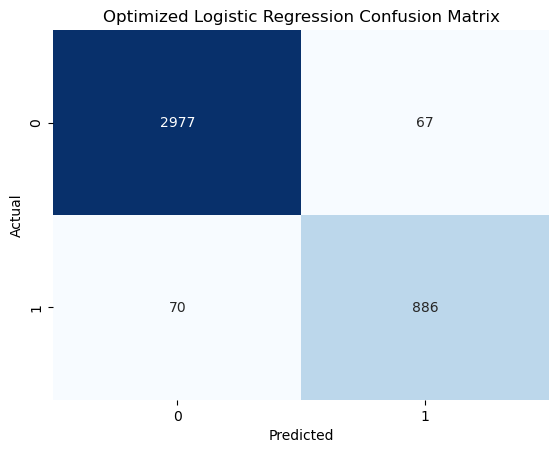

In [196]:
# confusion matrix
optimized_cm = confusion_matrix(
    y_test,
    optimized_predictions
)

sns.heatmap(
    optimized_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Optimized Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
5.5. Preprocesing Considerations
</h4>

The preprocessing pipeline was also considered during optimization. Numerical variables currently use median imputation and standardization, while categorical variables use most-frequent imputation and one-hot encoding. These preprocessing choices were retained because they are appropriate for the identified data-quality issues and Logistic Regression requirements. The optimization therefore focused on model hyperparameters rather than expanding the search space with additional preprocessing alternatives

<h4 style= "color: #008000; text-align: left; font-weight: bold;">
Optimization Results and Trade-offs
</h4>

GridSearchCV identified `C=10` with no class weighting as the best Logistic Regression configuration, achieving a mean cross-validation F1-score of approximately 0.922.

The parameter search showed that models without class weighting consistently achieved higher cross-validation F1-scores than their balanced counterparts. Increasing `C` from 0.1 to 10 also produced a small improvement, suggesting that weaker regularization was more appropriate for this dataset.

On the held-out test set, the optimized model achieved 96.6% accuracy, 93.0% precision, 92.7% recall, an F1-score of 92.8%, and a ROC-AUC of 0.995. Compared with the original Logistic Regression model, optimization produced a modest improvement rather than a substantial change in performance.

The optimized model retained 67 false positives while reducing false negatives from 73 to 70. As a result, the estimated business cost decreased from $3,934,000 to $3,910,000, representing an estimated reduction of $24,000.

The parameter comparison also demonstrates an important model trade-off. Applying balanced class weights did not improve the selected F1 metric, while the unweighted configurations produced stronger cross-validation results. Therefore, additional model complexity was not justified by the observed validation performance.

Overall, the optimization results support the use of the tuned Logistic Regression model (`C=10`, `class_weight=None`) as the final candidate model.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
None

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements